<a href="https://colab.research.google.com/github/hossam-mmagdy/NANOMATERIAL-CLASSIFICATION-RESEARCH/blob/main/nano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install numpy matplotlib seaborn scikit-learn pandas scipy

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy import stats, optimize, interpolate
from scipy.constants import hbar, electron_mass, elementary_charge, epsilon_0
from scipy.stats import gaussian_kde, pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from enum import Enum
from collections import defaultdict

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['xtick.major.width'] = 0.6
plt.rcParams['ytick.major.width'] = 0.6
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linewidth'] = 0.3
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['legend.fancybox'] = False

COLORS = {
    '0D': '#0173B2', '1D': '#DE8F05', '2D': '#029E73', '3D': '#D55E00',
    'CdSe': '#CC79A7', 'CdS': '#009E73', 'ZnS': '#0072B2', 'GaAs': '#D55E00', 'Au': '#F0E442',
    'sphere': '#56B4E9', 'rod': '#E69F00', 'sheet': '#009E73'
}

PHYS_CONST = {
    'hbar': hbar, 'm_e': electron_mass, 'e': elementary_charge,
    'eps0': epsilon_0, 'ev2j': 1.60218e-19
}

In [24]:
class Dimensionality(Enum):
    ZERO_D = "0D"
    ONE_D = "1D"
    TWO_D = "2D"
    THREE_D = "3D"

@dataclass
class Material:
    name: str
    symbol: str
    E_g_bulk: float
    m_e_eff: float
    m_h_eff: float
    eps_r: float
    rho: float
    structure: str

    def mu_eff(self):
        return (self.m_e_eff * self.m_h_eff) / (self.m_e_eff + self.m_h_eff)

MATERIALS = {
    'CdSe': Material('Cadmium Selenide', 'CdSe', 1.74, 0.13, 0.45, 10.6, 5.81, 'Wurtzite'),
    'CdS': Material('Cadmium Sulfide', 'CdS', 2.53, 0.21, 0.80, 8.6, 4.82, 'Wurtzite'),
    'ZnS': Material('Zinc Sulfide', 'ZnS', 3.68, 0.28, 0.60, 8.3, 4.09, 'Zinc Blende'),
    'GaAs': Material('Gallium Arsenide', 'GaAs', 1.42, 0.067, 0.50, 12.9, 5.32, 'Zinc Blende'),
    'Au': Material('Gold', 'Au', 0.0, 1.0, 1.0, 6.9, 19.32, 'FCC')
}

class BrusModel:
    def __init__(self, mat: Material):
        self.mat = mat
        self.hbar = PHYS_CONST['hbar']
        self.m_e = PHYS_CONST['m_e']
        self.e = PHYS_CONST['e']
        self.eps0 = PHYS_CONST['eps0']

    def E_quantum(self, R):
        mu = self.mat.mu_eff() * self.m_e
        return (self.hbar**2 * np.pi**2) / (2 * mu * R**2)

    def E_coulomb(self, R):
        if self.mat.eps_r == 0:
            return 0
        return -1.786 * (self.e**2) / (4 * np.pi * self.eps0 * self.mat.eps_r * R)

    def E_rydberg(self):
        mu = self.mat.mu_eff() * self.m_e
        eps = self.mat.eps_r
        return (mu * self.e**4) / (2 * (4 * np.pi * self.eps0 * eps * self.hbar)**2)

    def band_gap(self, d_nm):
        R = d_nm * 1e-9 / 2
        E_bulk = self.mat.E_g_bulk
        E_q = self.E_quantum(R) / 1.60218e-19
        E_c = self.E_coulomb(R) / 1.60218e-19
        E_r = self.E_rydberg() / 1.60218e-19
        E_total = E_bulk + E_q + E_c - 0.248 * E_r
        unc = abs(E_q) * 0.15
        return E_total, unc

class Geometry:
    @staticmethod
    def sphere(d):
        r = d / 2
        sa = 4 * np.pi * r**2
        vol = (4/3) * np.pi * r**3
        return sa, vol, sa/vol if vol > 0 else 0

    @staticmethod
    def rod(d, ar):
        r = d / 2
        l = d * ar
        sa = 2 * np.pi * r * (r + l)
        vol = np.pi * r**2 * l
        return sa, vol, sa/vol if vol > 0 else 0

    @staticmethod
    def sheet(l, w, t):
        sa = 2 * (l*w + l*t + w*t)
        vol = l * w * t
        return sa, vol, sa/vol if vol > 0 else 0

In [25]:
class NanoDataset:
    def __init__(self, n=1000, seed=42):
        self.n = n
        np.random.seed(seed)

    def generate(self):
        data = []
        for i in range(self.n):
            dim = np.random.choice(['0D', '1D', '2D', '3D'], p=[0.25, 0.25, 0.25, 0.25])

            if dim == '0D':
                size = np.clip(np.random.lognormal(1.5, 0.5), 2, 20)
                ar = np.random.normal(1.0, 0.1)
                mat_name = np.random.choice(['CdSe', 'CdS', 'ZnS'])
            elif dim == '1D':
                size = np.clip(np.random.lognormal(3.5, 0.6), 10, 100)
                ar = np.clip(np.random.lognormal(2.0, 0.5), 5, 50)
                mat_name = np.random.choice(['CdSe', 'GaAs', 'ZnS'])
            elif dim == '2D':
                size = np.clip(np.random.lognormal(5.0, 0.4), 50, 500)
                ar = np.random.uniform(0.01, 0.1)
                mat_name = np.random.choice(['CdSe', 'GaAs'])
            else:
                size = np.clip(np.random.lognormal(7.0, 0.5), 500, 5000)
                ar = np.random.uniform(0.5, 2.0)
                mat_name = np.random.choice(['CdSe', 'GaAs', 'ZnS'])

            calc = Geometry()
            if dim == '0D':
                sa, vol, sav = calc.sphere(size)
            elif dim == '1D':
                sa, vol, sav = calc.rod(size, ar)
            elif dim == '2D':
                t = size * ar
                sa, vol, sav = calc.sheet(size, size, t)
            else:
                sa, vol, sav = calc.sphere(size)

            mat = MATERIALS[mat_name]
            qm = BrusModel(mat)

            if dim in ['0D', '1D', '2D']:
                bg, bg_err = qm.band_gap(size)
            else:
                bg, bg_err = mat.E_g_bulk, 0.01

            data.append({
                'id': f"NM_{i:05d}",
                'dim': dim,
                'mat': mat_name,
                'size_nm': size,
                'ar': ar,
                'sa_nm2': sa,
                'vol_nm3': vol,
                'sav_nm': sav,
                'bg_ev': bg,
                'bg_err': bg_err,
                'structure': mat.structure,
                'density': mat.rho,
                'm_e': mat.m_e_eff,
                'm_h': mat.m_h_eff
            })

        return pd.DataFrame(data)

In [26]:
class ScientificFigure:
    def __init__(self, figsize=(11, 8.5), rows=2, cols=2):
        self.fig = plt.figure(figsize=figsize)
        self.gs = GridSpec(rows, cols, figure=self.fig, hspace=0.35, wspace=0.35)
        self.axs = []

    def label(self, ax, text, x=-0.15, y=1.02):
        from mpl_toolkits.mplot3d import Axes3D
        if isinstance(ax, Axes3D):
            ax.text2D(x, y, text, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')
        else:
            ax.text(x, y, text, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')

    def done(self, name=None):
        plt.tight_layout()
        if name:
            self.fig.savefig(f"{name}.pdf", dpi=300, bbox_inches='tight')
            self.fig.savefig(f"{name}.png", dpi=300, bbox_inches='tight')
        plt.show()
        return self.fig

class QuantumAnalysis(ScientificFigure):
    def __init__(self):
        super().__init__(figsize=(14, 10), rows=2, cols=3)

    def plot(self, df):
        ax1 = self.fig.add_subplot(self.gs[0, 0])
        ax2 = self.fig.add_subplot(self.gs[0, 1])
        ax3 = self.fig.add_subplot(self.gs[0, 2])
        ax4 = self.fig.add_subplot(self.gs[1, 0])
        ax5 = self.fig.add_subplot(self.gs[1, 1])
        ax6 = self.fig.add_subplot(self.gs[1, 2])

        mat_data = df[df['mat'] == 'CdSe']

        for dim in ['0D', '1D', '2D', '3D']:
            d = mat_data[mat_data['dim'] == dim].sort_values('size_nm')
            if len(d) > 0:
                ax1.errorbar(d['size_nm'], d['bg_ev'], yerr=d['bg_err'], fmt='o',
                           markersize=4, capsize=2, color=COLORS[dim], alpha=0.6, label=dim)

        qm = BrusModel(MATERIALS['CdSe'])
        sizes = np.linspace(2, 100, 200)
        bgs = [qm.band_gap(s)[0] for s in sizes]
        ax1.plot(sizes, bgs, 'k--', lw=1.5, label='Brus EMA')
        ax1.axhline(y=MATERIALS['CdSe'].E_g_bulk, color='gray', ls=':', lw=1, label=f"Bulk ({MATERIALS['CdSe'].E_g_bulk} eV)")
        ax1.set_xscale('log')
        ax1.set_xlabel('Diameter (nm)', fontweight='bold')
        ax1.set_ylabel('Band Gap (eV)', fontweight='bold')
        ax1.set_title('CdSe Quantum Confinement', fontweight='bold')
        ax1.legend(fontsize=7, loc='upper right')

        dims = ['0D', '1D', '2D', '3D']
        sz = [mat_data[mat_data['dim'] == d]['size_nm'].values for d in dims]
        bp = ax2.boxplot(sz, tick_labels=dims, patch_artist=True, showfliers=True)
        for patch, dim in zip(bp['boxes'], dims):
            patch.set_facecolor(COLORS[dim])
            patch.set_alpha(0.7)
        ax2.set_ylabel('Size (nm)', fontweight='bold')
        ax2.set_title('Size Distribution', fontweight='bold')
        ax2.set_yscale('log')

        for dim in ['0D', '1D', '2D']:
            d = df[df['dim'] == dim]
            if len(d) > 0:
                x, y = d['size_nm'].values, d['bg_ev'].values
                logx, logy = np.log(x), np.log(y - MATERIALS[d['mat'].iloc[0]].E_g_bulk + 0.01)
                slope, intercept, r, _, _ = stats.linregress(logx, logy)
                ax3.scatter(x, y - d['bg_ev'].iloc[0] + 1.74, c=COLORS[dim], s=20, alpha=0.5,
                          label=f'{dim}: α={slope:.2f}')

        ax3.set_xscale('log')
        ax3.set_yscale('log')
        ax3.set_xlabel('Size (nm)', fontweight='bold')
        ax3.set_ylabel('ΔE (eV)', fontweight='bold')
        ax3.set_title('Confinement Scaling Laws', fontweight='bold')
        ax3.legend(fontsize=7)

        mats = ['CdSe', 'CdS', 'ZnS', 'GaAs']
        for mat in mats:
            d = df[df['mat'] == mat]
            if len(d) > 0:
                ax4.scatter(d['size_nm'], d['bg_ev'], c=COLORS[mat], s=15, alpha=0.5, label=mat)

        ax4.set_xscale('log')
        ax4.set_xlabel('Size (nm)', fontweight='bold')
        ax4.set_ylabel('Band Gap (eV)', fontweight='bold')
        ax4.set_title('Material Comparison', fontweight='bold')
        ax4.legend(fontsize=7)

        bg_stats = df.groupby('dim')['bg_ev'].agg(['mean', 'std', 'median'])
        x = np.arange(len(bg_stats))
        ax5.bar(x, bg_stats['mean'], yerr=bg_stats['std'], capsize=5,
               color=[COLORS[d] for d in bg_stats.index], alpha=0.7, edgecolor='black')
        ax5.set_xticks(x)
        ax5.set_xticklabels(bg_stats.index)
        ax5.set_ylabel('Band Gap (eV)', fontweight='bold')
        ax5.set_title('Mean Band Gap by Dimension', fontweight='bold')

        for i, (m, s) in enumerate(zip(bg_stats['mean'], bg_stats['std'])):
            ax5.text(i, m/2, f'σ={s:.2f}', ha='center', fontsize=8, fontweight='bold')

        dim_map = {'0D': 0, '1D': 1, '2D': 2, '3D': 3}
        y_num = df['dim'].map(dim_map)
        X = df[['size_nm', 'bg_ev']].values

        lda = LinearDiscriminantAnalysis()
        lda.fit(X, y_num)
        X_lda = lda.transform(X)

        for dim in ['0D', '1D', '2D', '3D']:
            mask = df['dim'] == dim
            ax6.scatter(X_lda[mask, 0], np.zeros(np.sum(mask)) + np.random.normal(0, 0.02, np.sum(mask)),
                       c=COLORS[dim], s=30, alpha=0.6, label=dim)

        ax6.set_xlabel('LD1', fontweight='bold')
        ax6.set_title('LDA Classification', fontweight='bold')
        ax6.set_yticks([])
        ax6.legend(fontsize=7)

        self.label(ax1, 'a')
        self.label(ax2, 'b')
        self.label(ax3, 'c')
        self.label(ax4, 'd')
        self.label(ax5, 'e')
        self.label(ax6, 'f')

        return self.done('figure1_quantum_analysis')

In [27]:
class SurfaceAnalysis(ScientificFigure):
    def __init__(self):
        super().__init__(figsize=(14, 10), rows=2, cols=3)

    def plot(self, df):
        ax1 = self.fig.add_subplot(self.gs[0, 0])
        ax2 = self.fig.add_subplot(self.gs[0, 1])
        ax3 = self.fig.add_subplot(self.gs[0, 2])
        ax4 = self.fig.add_subplot(self.gs[1, 0])
        ax5 = self.fig.add_subplot(self.gs[1, 1])
        ax6 = self.fig.add_subplot(self.gs[1, 2])

        for dim in ['0D', '1D', '2D']:
            d = df[df['dim'] == dim]
            if len(d) > 0:
                x, y = d['size_nm'].values, d['sav_nm'].values
                logx, logy = np.log(x), np.log(y)
                slope, intercept, r, _, _ = stats.linregress(logx, logy)

                ax1.scatter(x, y, c=COLORS[dim], s=20, alpha=0.5,
                          label=f'{dim}: α={slope:.2f}, R²={r**2:.3f}')

                xf = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
                yf = np.exp(intercept) * xf**slope
                ax1.plot(xf, yf, '--', color=COLORS[dim], lw=1.5)

        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlabel('Size (nm)', fontweight='bold')
        ax1.set_ylabel('SA:V Ratio (nm⁻¹)', fontweight='bold')
        ax1.set_title('SA:V Scaling Laws', fontweight='bold')
        ax1.legend(fontsize=7)

        ax2_3d = self.fig.add_subplot(self.gs[0, 1], projection='3d')
        for dim in ['0D', '1D', '2D']:
            d = df[df['dim'] == dim]
            if len(d) > 0:
                ax2_3d.scatter(d['size_nm'], d['ar'], d['sav_nm'],
                             c=COLORS[dim], s=15, alpha=0.5, label=dim)

        ax2_3d.set_xlabel('Size (nm)', fontweight='bold')
        ax2_3d.set_ylabel('Aspect Ratio', fontweight='bold')
        ax2_3d.set_zlabel('SA:V (nm⁻¹)', fontweight='bold')
        ax2_3d.set_title('3D Morphology Space', fontweight='bold')

        stats_df = df.groupby('dim')['sav_nm'].agg(['mean', 'std', 'median', 'count'])
        x = np.arange(len(stats_df))
        ax3.bar(x, stats_df['mean'], yerr=stats_df['std'], capsize=5,
               color=[COLORS[d] for d in stats_df.index], alpha=0.7, edgecolor='black')
        ax3.set_xticks(x)
        ax3.set_xticklabels(stats_df.index)
        ax3.set_ylabel('Mean SA:V (nm⁻¹)', fontweight='bold')
        ax3.set_title('SA:V Statistics', fontweight='bold')

        for i, (m, c) in enumerate(zip(stats_df['mean'], stats_df['count'])):
            ax3.text(i, m/2, f'n={int(c)}', ha='center', fontsize=8, fontweight='bold')

        dims = ['0D', '1D', '2D', '3D']
        sav_data = [df[df['dim'] == d]['sav_nm'].values for d in dims]
        vp = ax4.violinplot(sav_data, positions=range(len(dims)), showmeans=True, showmedians=True)
        for i, pc in enumerate(vp['bodies']):
            pc.set_facecolor(COLORS[dims[i]])
            pc.set_alpha(0.7)
        ax4.set_xticks(range(len(dims)))
        ax4.set_xticklabels(dims)
        ax4.set_ylabel('SA:V Ratio (nm⁻¹)', fontweight='bold')
        ax4.set_title('Distribution Density', fontweight='bold')
        ax4.set_yscale('log')

        corr_data = df[['size_nm', 'ar', 'sav_nm', 'bg_ev', 'vol_nm3', 'sa_nm2']].corr()
        im = ax5.imshow(corr_data, cmap='RdBu_r', vmin=-1, vmax=1)
        ax5.set_xticks(range(len(corr_data.columns)))
        ax5.set_yticks(range(len(corr_data.columns)))
        labels = ['Size', 'AR', 'SA:V', 'BG', 'Vol', 'SA']
        ax5.set_xticklabels(labels, rotation=45, ha='right')
        ax5.set_yticklabels(labels)

        for i in range(len(labels)):
            for j in range(len(labels)):
                ax5.text(j, i, f'{corr_data.iloc[i, j]:.2f}', ha="center", va="center",
                        color="white" if abs(corr_data.iloc[i, j]) > 0.5 else "black", fontsize=8)

        ax5.set_title('Correlation Matrix', fontweight='bold')
        plt.colorbar(im, ax=ax5, fraction=0.046)

        for dim in ['0D', '1D', '2D']:
            d = df[df['dim'] == dim]
            if len(d) > 0:
                density = gaussian_kde(np.log(d['sav_nm']))
                xs = np.linspace(np.log(d['sav_nm'].min()), np.log(d['sav_nm'].max()), 200)
                ax6.fill_between(np.exp(xs), density(xs), alpha=0.5, color=COLORS[dim], label=dim)
                ax6.plot(np.exp(xs), density(xs), color=COLORS[dim], lw=2)

        ax6.set_xlabel('SA:V Ratio (nm⁻¹)', fontweight='bold')
        ax6.set_ylabel('Probability Density', fontweight='bold')
        ax6.set_title('SA:V Distributions', fontweight='bold')
        ax6.set_xscale('log')
        ax6.legend(fontsize=7)

        self.label(ax1, 'a')
        self.label(ax2_3d, 'b', x=-0.1)
        self.label(ax3, 'c')
        self.label(ax4, 'd')
        self.label(ax5, 'e')
        self.label(ax6, 'f')

        return self.done('figure2_surface_analysis')

In [29]:
class MLAnalysis(ScientificFigure):
    def __init__(self):
        super().__init__(figsize=(14, 10), rows=2, cols=3)

    def plot(self, df):
        ax1 = self.fig.add_subplot(self.gs[0, 0])
        ax2 = self.fig.add_subplot(self.gs[0, 1])
        ax3 = self.fig.add_subplot(self.gs[0, 2])
        ax4 = self.fig.add_subplot(self.gs[1, 0])
        ax5 = self.fig.add_subplot(self.gs[1, 1])
        ax6 = self.fig.add_subplot(self.gs[1, 2])

        features = ['size_nm', 'ar', 'bg_ev', 'sav_nm', 'vol_nm3']
        X = df[features].values
        y = df['dim'].values

        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)

        pca = PCA()
        X_pca = pca.fit_transform(Xs)

        for dim in ['0D', '1D', '2D', '3D']:
            mask = y == dim
            ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=COLORS[dim], s=30, alpha=0.6, label=dim, edgecolors='none')

        ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontweight='bold')
        ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontweight='bold')
        ax1.set_title('PCA Projection', fontweight='bold')
        ax1.legend(fontsize=7)

        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(Xs)

        for dim in ['0D', '1D', '2D', '3D']:
            mask = y == dim
            ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=COLORS[dim], s=30, alpha=0.6, label=dim, edgecolors='none')

        ax2.set_xlabel('t-SNE 1', fontweight='bold')
        ax2.set_ylabel('t-SNE 2', fontweight='bold')
        ax2.set_title('t-SNE Embedding', fontweight='bold')

        loadings = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2])
        x_pos = np.arange(len(features))
        width = 0.35

        ax3.bar(x_pos - width/2, loadings[:, 0], width, label=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
               color=COLORS['0D'], alpha=0.7)
        ax3.bar(x_pos + width/2, loadings[:, 1], width, label=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
               color=COLORS['1D'], alpha=0.7)

        ax3.set_xticks(x_pos)
        ax3.set_xticklabels([f.replace('_', '\n') for f in features], fontsize=7)
        ax3.set_ylabel('Loading', fontweight='bold')
        ax3.set_title('PCA Loadings', fontweight='bold')
        ax3.legend(fontsize=7)
        ax3.axhline(y=0, color='black', linewidth=0.5)

        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        clusters = km.fit_predict(Xs)

        sil = silhouette_score(Xs, clusters)
        cal = calinski_harabasz_score(Xs, clusters)
        db = davies_bouldin_score(Xs, clusters)

        dim_map = {'0D': 0, '1D': 1, '2D': 2, '3D': 3}
        y_num = np.array([dim_map[d] for d in y])
        cm = confusion_matrix(y_num, clusters)

        im = ax4.imshow(cm, cmap='Blues')
        ax4.set_xticks(range(4))
        ax4.set_yticks(range(4))
        ax4.set_xticklabels(['0D', '1D', '2D', '3D'])
        ax4.set_yticklabels(['0D', '1D', '2D', '3D'])
        ax4.set_xlabel('Predicted Cluster', fontweight='bold')
        ax4.set_ylabel('True Dimension', fontweight='bold')
        ax4.set_title(f'K-Means Confusion\nSil={sil:.3f}, CH={cal:.1f}', fontweight='bold')

        for i in range(4):
            for j in range(4):
                ax4.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max()/2 else "black", fontweight='bold')

        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(rf, Xs, y, cv=cv, scoring='accuracy')

        rf.fit(Xs, y)
        importances = rf.feature_importances_

        ax5.barh(features, importances, color=[COLORS['0D'], COLORS['1D'], COLORS['2D'], COLORS['3D'], COLORS['CdSe']], alpha=0.7)
        ax5.set_xlabel('Importance', fontweight='bold')
        ax5.set_title(f'RF Feature Importance\nCV Acc: {scores.mean():.3f}±{scores.std():.3f}', fontweight='bold')

        methods = ['K-Means', 'Agglomerative', 'DBSCAN']
        scores_list = []

        km_sil = silhouette_score(Xs, KMeans(n_clusters=4, random_state=42).fit_predict(Xs))
        agg = AgglomerativeClustering(n_clusters=4)
        agg_sil = silhouette_score(Xs, agg.fit_predict(Xs))
        dbscan = DBSCAN(eps=0.5, min_samples=5)
        db_labels = dbscan.fit_predict(Xs)
        if len(set(db_labels)) > 1:
            db_sil = silhouette_score(Xs, db_labels)
        else:
            db_sil = -1

        scores_list = [km_sil, agg_sil, db_sil]

        bars = ax6.bar(methods, scores_list, color=[COLORS['0D'], COLORS['1D'], COLORS['2D']], alpha=0.7, edgecolor='black')
        ax6.set_ylabel('Silhouette Score', fontweight='bold')
        ax6.set_title('Clustering Comparison', fontweight='bold')
        ax6.set_ylim(-0.2, 1)

        for bar, score in zip(bars, scores_list):
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{score:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        self.label(ax1, 'a')
        self.label(ax2, 'b')
        self.label(ax3, 'c')
        self.label(ax4, 'd')
        self.label(ax5, 'e')
        self.label(ax6, 'f')

        return self.done('figure3_ml_analysis')

In [30]:
class ComprehensiveAnalysis(ScientificFigure):
    def __init__(self):
        super().__init__(figsize=(16, 12), rows=3, cols=3)

    def plot(self, df):
        results = {}

        ax1 = self.fig.add_subplot(self.gs[0, 0])
        ax2 = self.fig.add_subplot(self.gs[0, 1])
        ax3 = self.fig.add_subplot(self.gs[0, 2])
        ax4 = self.fig.add_subplot(self.gs[1, 0])
        ax5 = self.fig.add_subplot(self.gs[1, 1])
        ax6 = self.fig.add_subplot(self.gs[1, 2])
        ax7 = self.fig.add_subplot(self.gs[2, 0])
        ax8 = self.fig.add_subplot(self.gs[2, 1])
        ax9 = self.fig.add_subplot(self.gs[2, 2])

        for mat in ['CdSe', 'CdS', 'ZnS', 'GaAs']:
            d = df[df['mat'] == mat]
            if len(d) > 0:
                ax1.scatter(d['size_nm'], d['bg_ev'], c=COLORS[mat], s=20, alpha=0.5, label=mat)

        ax1.set_xscale('log')
        ax1.set_xlabel('Size (nm)', fontweight='bold')
        ax1.set_ylabel('Band Gap (eV)', fontweight='bold')
        ax1.set_title('All Materials: Size vs Band Gap', fontweight='bold')
        ax1.legend(fontsize=7)

        for dim in ['0D', '1D', '2D', '3D']:
            d = df[df['dim'] == dim]
            if len(d) > 0:
                ax2.hist(d['bg_ev'], bins=30, alpha=0.5, color=COLORS[dim], label=dim, density=True)

        ax2.set_xlabel('Band Gap (eV)', fontweight='bold')
        ax2.set_ylabel('Density', fontweight='bold')
        ax2.set_title('Band Gap Distributions', fontweight='bold')
        ax2.legend(fontsize=7)

        mat_counts = df['mat'].value_counts()
        ax3.pie(mat_counts.values, labels=mat_counts.index, autopct='%1.1f%%',
               colors=[COLORS[m] for m in mat_counts.index])
        ax3.set_title('Material Composition', fontweight='bold')

        pivot = df.pivot_table(values='bg_ev', index='dim', columns='mat', aggfunc='mean')
        im = ax4.imshow(pivot.values, cmap='viridis', aspect='auto')
        ax4.set_xticks(range(len(pivot.columns)))
        ax4.set_yticks(range(len(pivot.index)))
        ax4.set_xticklabels(pivot.columns)
        ax4.set_yticklabels(pivot.index)
        ax4.set_title('Mean Band Gap Matrix', fontweight='bold')

        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                if not np.isnan(pivot.iloc[i, j]):
                    ax4.text(j, i, f'{pivot.iloc[i, j]:.2f}', ha="center", va="center",
                            color="white" if pivot.iloc[i, j] > pivot.values.mean() else "black", fontsize=8)

        plt.colorbar(im, ax=ax4, fraction=0.046)

        for dim in ['0D', '1D', '2D']:
            d = df[df['dim'] == dim]
            if len(d) > 0:
                x, y = d['size_nm'].values, d['vol_nm3'].values
                ax5.scatter(x, y, c=COLORS[dim], s=20, alpha=0.5, label=dim)

                z = np.polyfit(np.log(x), np.log(y), 1)
                p = np.poly1d(z)
                xf = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
                ax5.plot(xf, np.exp(p(np.log(xf))), '--', color=COLORS[dim], lw=1.5)

        ax5.set_xscale('log')
        ax5.set_yscale('log')
        ax5.set_xlabel('Size (nm)', fontweight='bold')
        ax5.set_ylabel('Volume (nm³)', fontweight='bold')
        ax5.set_title('Size-Volume Scaling', fontweight='bold')
        ax5.legend(fontsize=7)

        for dim in ['0D', '1D', '2D', '3D']:
            d = df[df['dim'] == dim]
            if len(d) > 0:
                x, y = d['sa_nm2'].values, d['vol_nm3'].values
                ax6.scatter(x, y, c=COLORS[dim], s=20, alpha=0.5, label=dim)

        ax6.set_xscale('log')
        ax6.set_yscale('log')
        ax6.set_xlabel('Surface Area (nm²)', fontweight='bold')
        ax6.set_ylabel('Volume (nm³)', fontweight='bold')
        ax6.set_title('SA vs Volume', fontweight='bold')
        ax6.legend(fontsize=7)

        stats_summary = df.groupby('dim').agg({
            'size_nm': ['mean', 'std', 'min', 'max'],
            'bg_ev': ['mean', 'std'],
            'sav_nm': ['mean', 'std'],
            'vol_nm3': ['mean', 'std']
        })

        x = np.arange(len(stats_summary))
        width = 0.2

        ax7.bar(x - 1.5*width, stats_summary[('size_nm', 'mean')], width, yerr=stats_summary[('size_nm', 'std')],
               label='Size', color=COLORS['0D'], alpha=0.7, capsize=3)
        ax7.bar(x - 0.5*width, stats_summary[('bg_ev', 'mean')]*10, width, yerr=stats_summary[('bg_ev', 'std')]*10,
               label='BG×10', color=COLORS['1D'], alpha=0.7, capsize=3)
        ax7.bar(x + 0.5*width, stats_summary[('sav_nm', 'mean')], width, yerr=stats_summary[('sav_nm', 'std')],
               label='SA:V', color=COLORS['2D'], alpha=0.7, capsize=3)
        ax7.bar(x + 1.5*width, np.log10(stats_summary[('vol_nm3', 'mean')]), width,
               label='log₁₀(Vol)', color=COLORS['3D'], alpha=0.7, capsize=3)

        ax7.set_xticks(x)
        ax7.set_xticklabels(stats_summary.index)
        ax7.set_ylabel('Normalized Values', fontweight='bold')
        ax7.set_title('Multi-Parameter Summary', fontweight='bold')
        ax7.legend(fontsize=7)

        for dim in ['0D', '1D', '2D', '3D']:
            d = df[df['dim'] == dim]
            if len(d) > 0:
                ax8.scatter(d['ar'], d['sav_nm'], c=COLORS[dim], s=20, alpha=0.5, label=dim)

        ax8.set_xscale('log')
        ax8.set_yscale('log')
        ax8.set_xlabel('Aspect Ratio', fontweight='bold')
        ax8.set_ylabel('SA:V Ratio (nm⁻¹)', fontweight='bold')
        ax8.set_title('Aspect Ratio vs SA:V', fontweight='bold')
        ax8.legend(fontsize=7)

        df['density_class'] = pd.cut(df['sav_nm'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
        density_counts = df.groupby(['dim', 'density_class']).size().unstack(fill_value=0)

        density_counts.plot(kind='bar', stacked=True, ax=ax9, colormap='viridis', alpha=0.8)
        ax9.set_xlabel('Dimensionality', fontweight='bold')
        ax9.set_ylabel('Count', fontweight='bold')
        ax9.set_title('SA:V Density Classification', fontweight='bold')
        ax9.legend(title='SA:V Class', fontsize=6, loc='upper right')
        ax9.set_xticklabels(ax9.get_xticklabels(), rotation=0)

        self.label(ax1, 'a')
        self.label(ax2, 'b')
        self.label(ax3, 'c')
        self.label(ax4, 'd')
        self.label(ax5, 'e')
        self.label(ax6, 'f')
        self.label(ax7, 'g')
        self.label(ax8, 'h')
        self.label(ax9, 'i')

        results['stats_summary'] = stats_summary
        results['material_distribution'] = df['mat'].value_counts().to_dict()
        results['dimension_distribution'] = df['dim'].value_counts().to_dict()
        results['mean_band_gaps'] = df.groupby('dim')['bg_ev'].mean().to_dict()
        results['mean_sav'] = df.groupby('dim')['sav_nm'].mean().to_dict()

        return self.done('figure4_comprehensive'), results

In [31]:
def statistical_analysis(df):
    print("\n" + "="*80)
    print("COMPREHENSIVE STATISTICAL ANALYSIS")
    print("="*80)

    print("\n[1] DESCRIPTIVE STATISTICS BY DIMENSIONALITY")
    print("-" * 60)

    desc_stats = df.groupby('dim')[['size_nm', 'bg_ev', 'sav_nm', 'vol_nm3', 'ar']].describe()
    print(desc_stats.round(4))

    print("\n[2] ANOVA: Band Gap Differences Across Dimensions")
    print("-" * 60)

    from scipy.stats import f_oneway, kruskal, tukey_hsd

    groups = [df[df['dim'] == d]['bg_ev'].values for d in ['0D', '1D', '2D', '3D']]
    f_stat, p_val = f_oneway(*groups)
    h_stat, p_val_k = kruskal(*groups)

    print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.2e}")
    print(f"Kruskal-Wallis H: {h_stat:.4f}, p-value: {p_val_k:.2e}")

    if p_val < 0.05:
        print("\nSignificant differences detected. Post-hoc Tukey HSD:")
        res = tukey_hsd(*groups)
        print(res)

    print("\n[3] CORRELATION ANALYSIS")
    print("-" * 60)

    corr_vars = ['size_nm', 'ar', 'bg_ev', 'sav_nm', 'vol_nm3']
    corr_matrix = df[corr_vars].corr(method='pearson')

    print("Pearson Correlation Matrix:")
    print(corr_matrix.round(4))

    print("\nSpearman Rank Correlations:")
    for i, var1 in enumerate(corr_vars):
        for j, var2 in enumerate(corr_vars):
            if i < j:
                rho, p = spearmanr(df[var1], df[var2])
                print(f"  {var1} vs {var2}: ρ={rho:.4f}, p={p:.2e}")

    print("\n[4] REGRESSION ANALYSIS: Size vs Band Gap")
    print("-" * 60)

    for dim in ['0D', '1D', '2D']:
        d = df[df['dim'] == dim]
        if len(d) > 0:
            x, y = np.log(d['size_nm']), d['bg_ev']
            slope, intercept, r, p, se = stats.linregress(x, y)
            print(f"\n{dim}:")
            print(f"  Slope: {slope:.4f} ± {se:.4f}")
            print(f"  R²: {r**2:.4f}")
            print(f"  p-value: {p:.2e}")
            print(f"  Equation: E_g = {intercept:.4f} + {slope:.4f}·ln(size)")

    print("\n[5] EFFECT SIZES")
    print("-" * 60)

    bg_means = df.groupby('dim')['bg_ev'].mean()
    bg_stds = df.groupby('dim')['bg_ev'].std()
    pooled_std = np.sqrt(np.mean(bg_stds**2))

    print("Cohen's d (vs 3D bulk):")
    for dim in ['0D', '1D', '2D']:
        d = (bg_means[dim] - bg_means['3D']) / pooled_std
        print(f"  {dim}: d = {d:.4f} ({'Large' if abs(d) > 0.8 else 'Medium' if abs(d) > 0.5 else 'Small'} effect)")

    print("\n[6] POWER ANALYSIS")
    print("-" * 60)

    from statsmodels.stats.power import FTestAnovaPower

    power_analysis = FTestAnovaPower()
    effect_size = f_stat / np.sqrt(len(df))
    power = power_analysis.solve_power(effect_size=effect_size, nobs=len(df), alpha=0.05, k_groups=4)
    print(f"Observed power: {power:.4f}")

    return {
        'anova_f': f_stat,
        'anova_p': p_val,
        'correlation_matrix': corr_matrix,
        'effect_sizes': {dim: (bg_means[dim] - bg_means['3D']) / pooled_std for dim in ['0D', '1D', '2D']}
    }

NANOMATERIAL CLASSIFICATION RESEARCH FRAMEWORK v2.0
Publication-Ready Scientific Analysis

[PHASE 1] Data Generation
------------------------------------------------------------
Generated 1000 synthetic nanomaterial samples
Features: ['id', 'dim', 'mat', 'size_nm', 'ar', 'sa_nm2', 'vol_nm3', 'sav_nm', 'bg_ev', 'bg_err', 'structure', 'density', 'm_e', 'm_h']

[PHASE 2] Data Validation
------------------------------------------------------------
Missing values: 0
Duplicate IDs: 0

Dimensionality distribution:
  0D: 269 (26.9%)
  1D: 223 (22.3%)
  2D: 254 (25.4%)
  3D: 254 (25.4%)

Material distribution:
  CdSe: 385 (38.5%)
  GaAs: 293 (29.3%)
  ZnS: 230 (23.0%)
  CdS: 92 (9.2%)

[PHASE 3] Generating Figure 1: Quantum Confinement Analysis


/tmp/ipykernel_382/2620697714.py:67: RuntimeWarning: invalid value encountered in log
  logx, logy = np.log(x), np.log(y - MATERIALS[d['mat'].iloc[0]].E_g_bulk + 0.01)
/tmp/ipykernel_382/2620697714.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


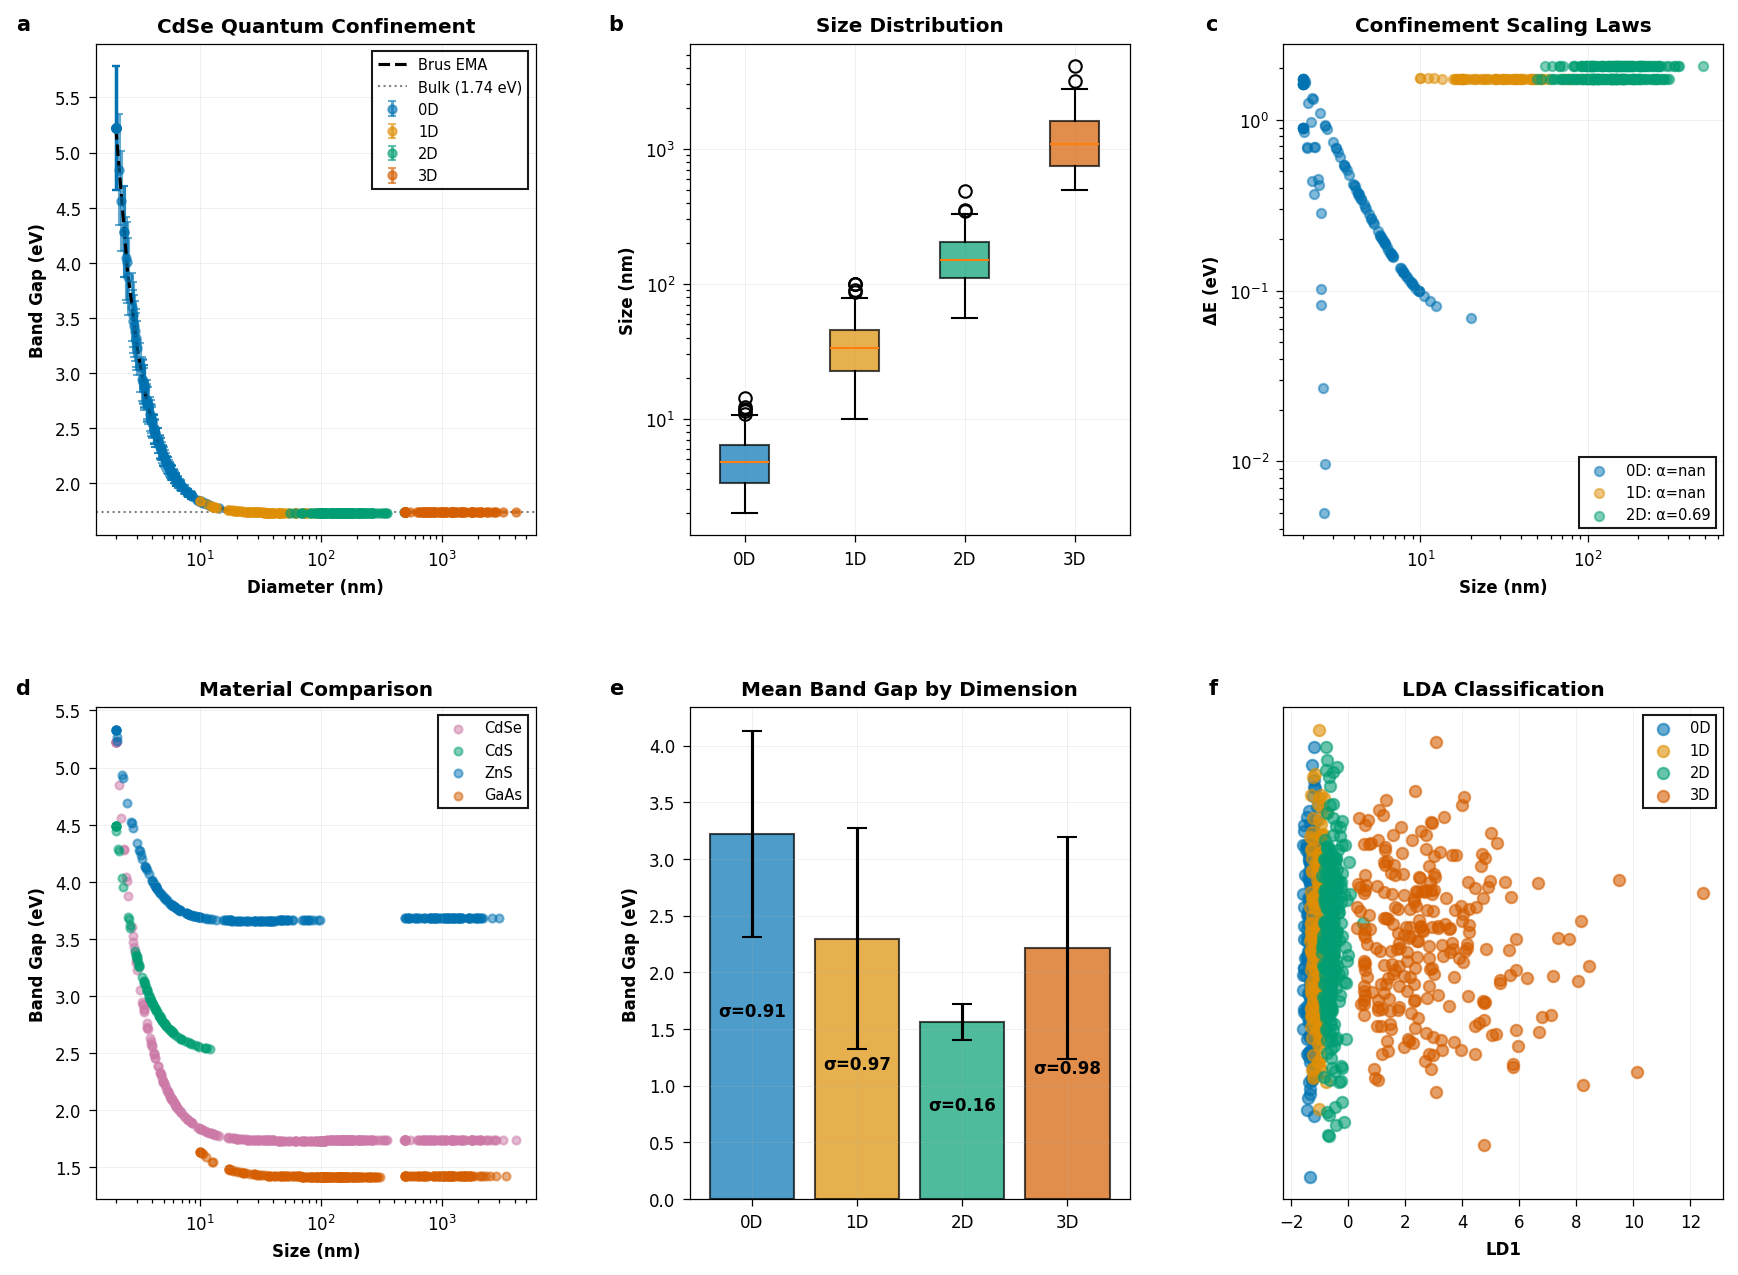


[PHASE 4] Generating Figure 2: Surface Area Analysis


/tmp/ipykernel_382/2620697714.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


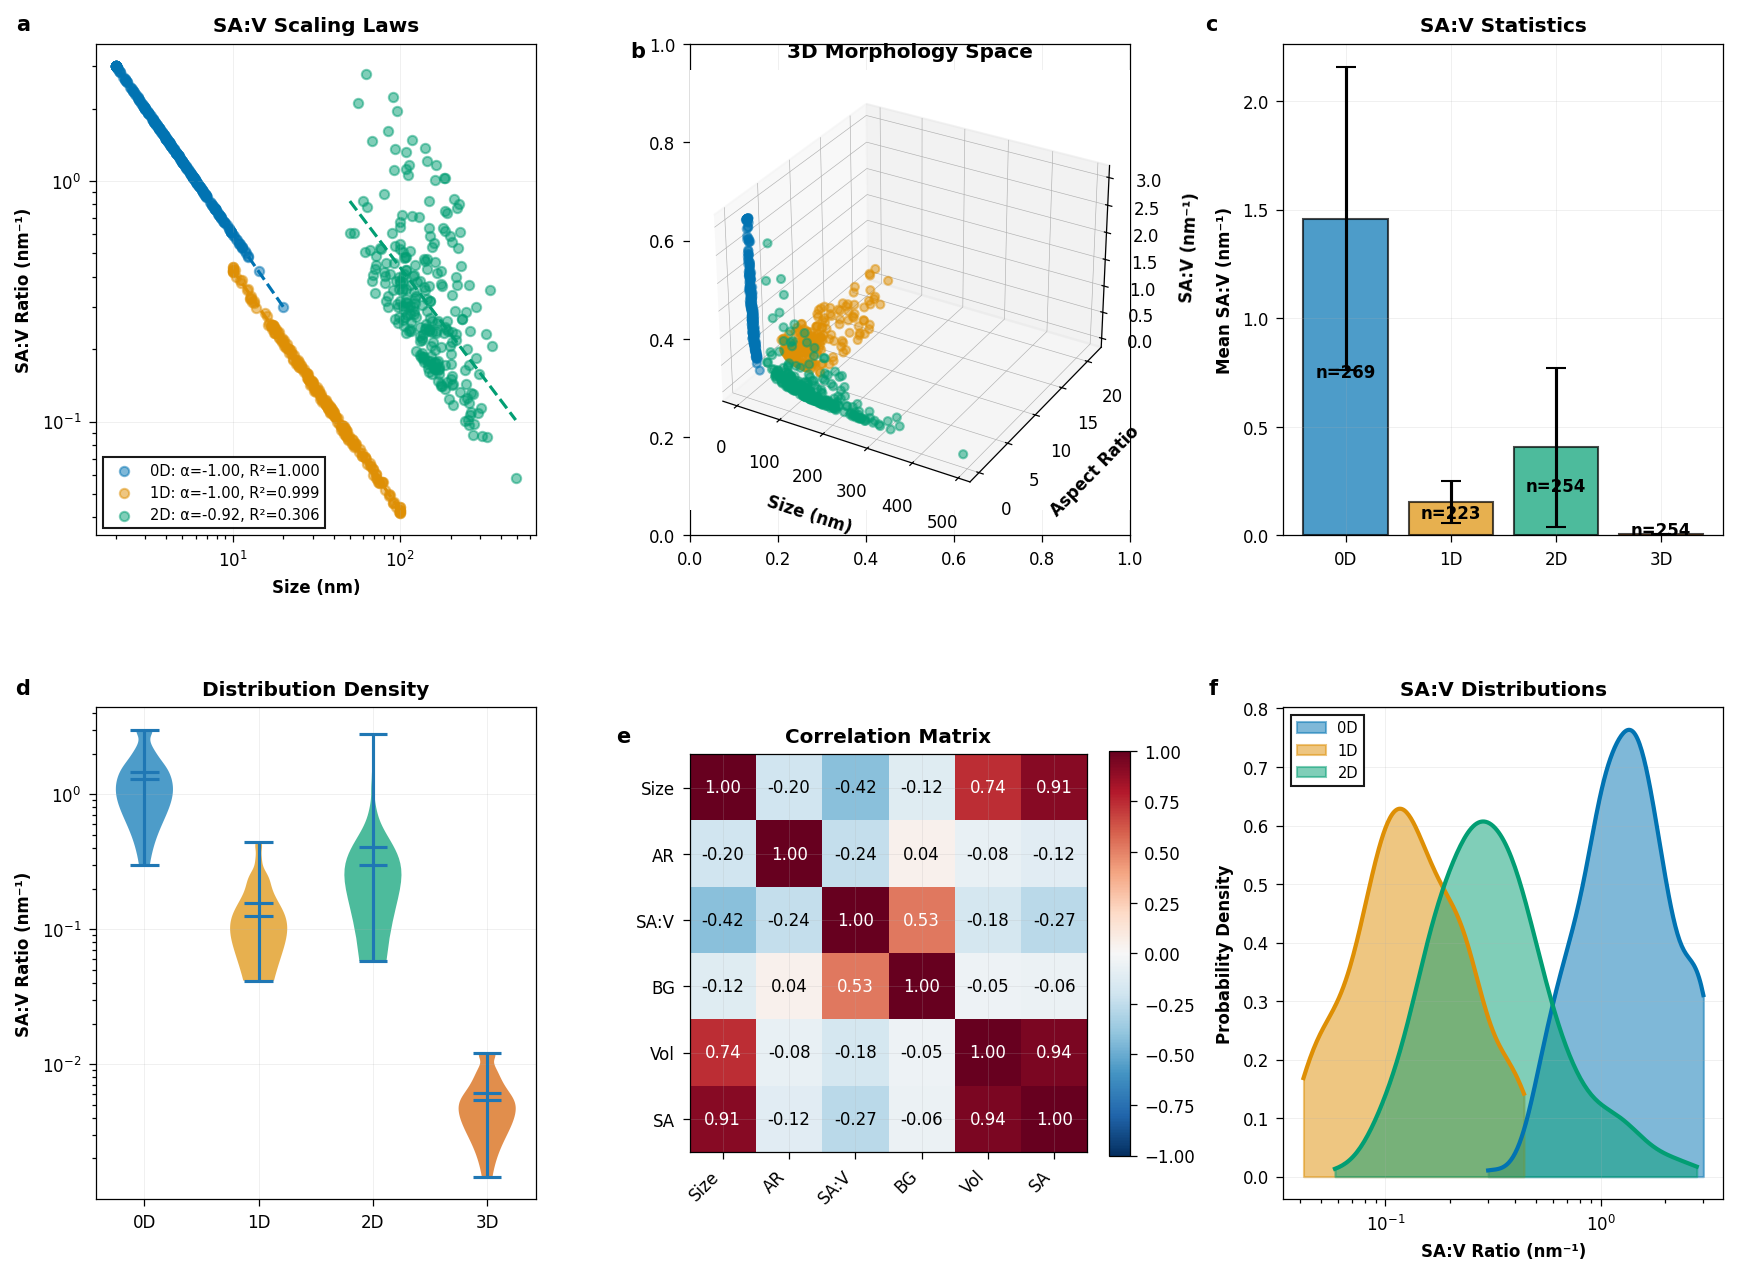


[PHASE 5] Generating Figure 3: Machine Learning Analysis


/tmp/ipykernel_382/2620697714.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


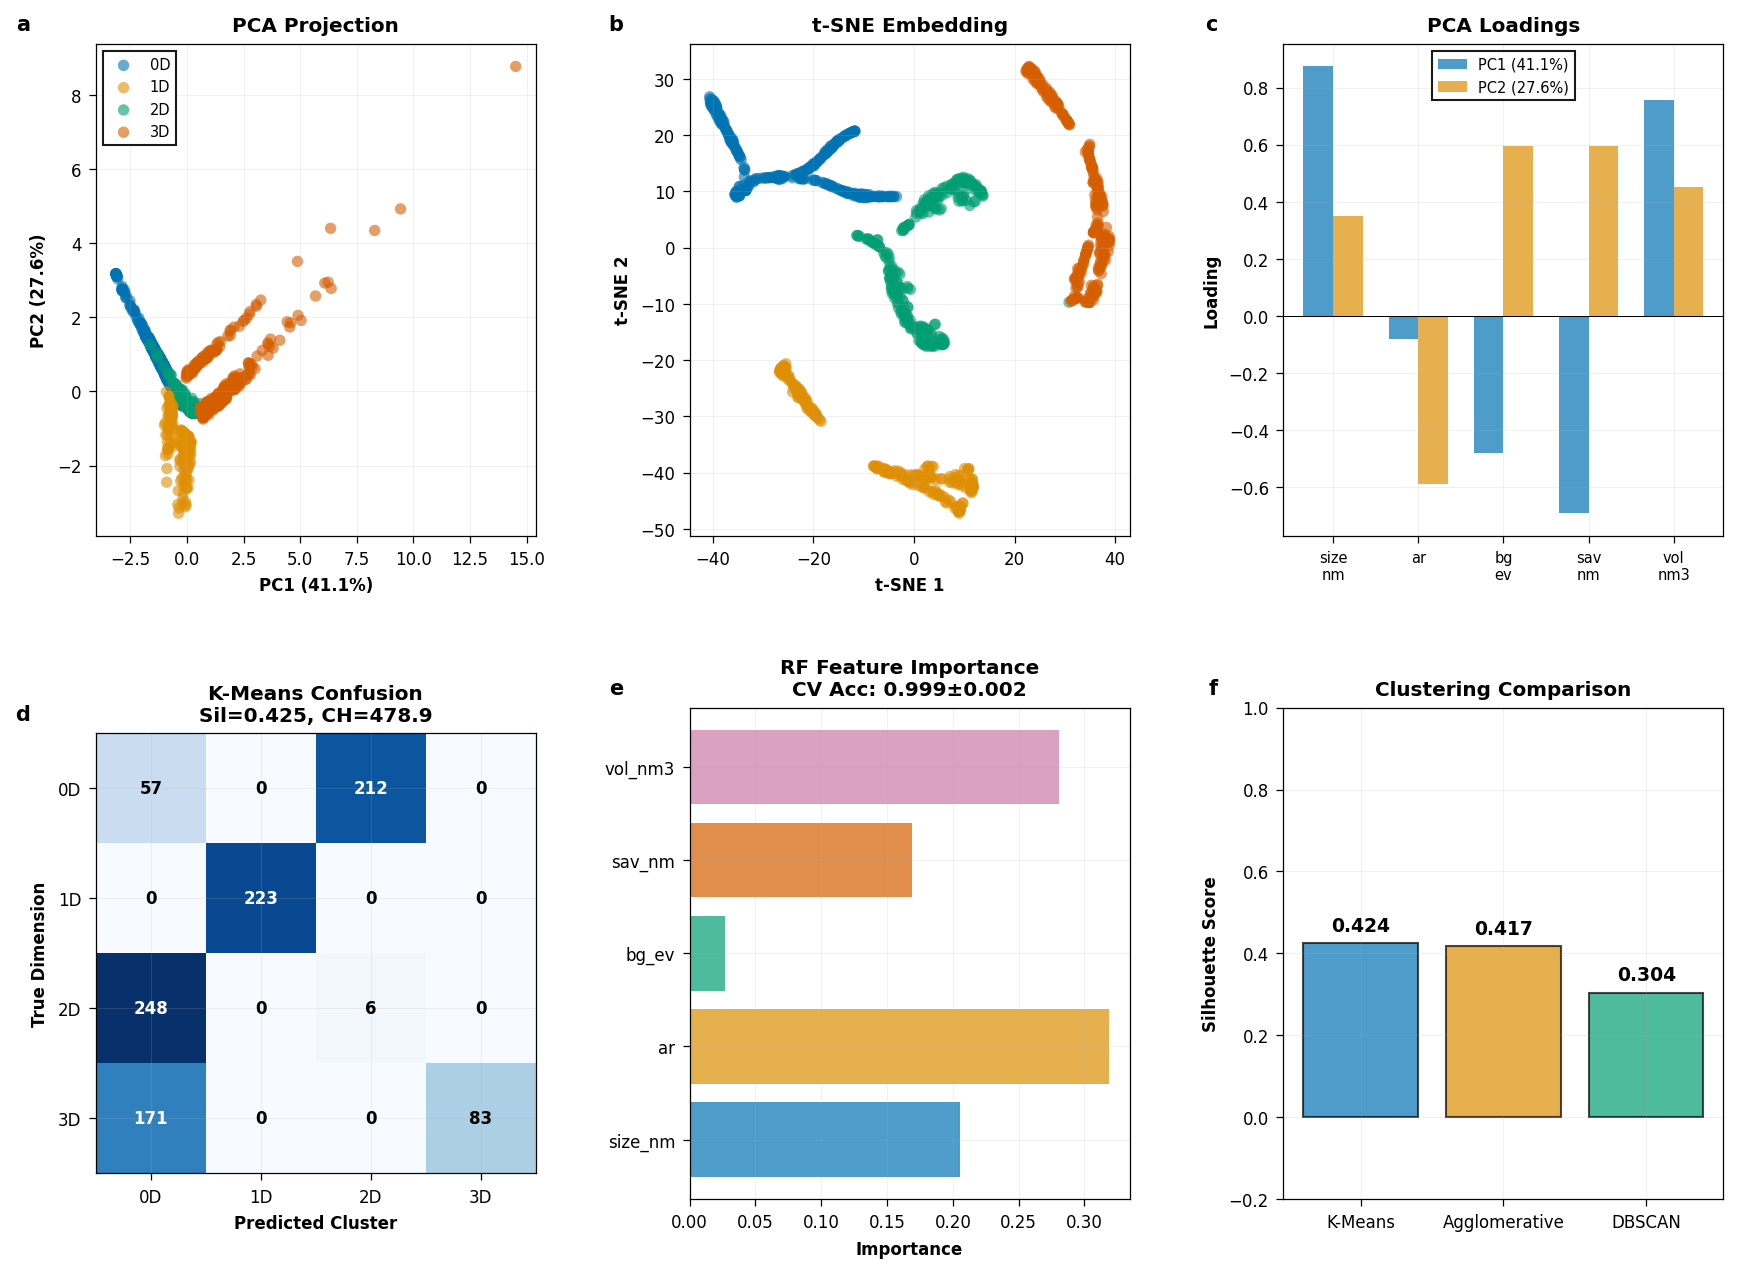


[PHASE 6] Generating Figure 4: Comprehensive Analysis


/tmp/ipykernel_382/2450338749.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  density_counts = df.groupby(['dim', 'density_class']).size().unstack(fill_value=0)
/tmp/ipykernel_382/2620697714.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


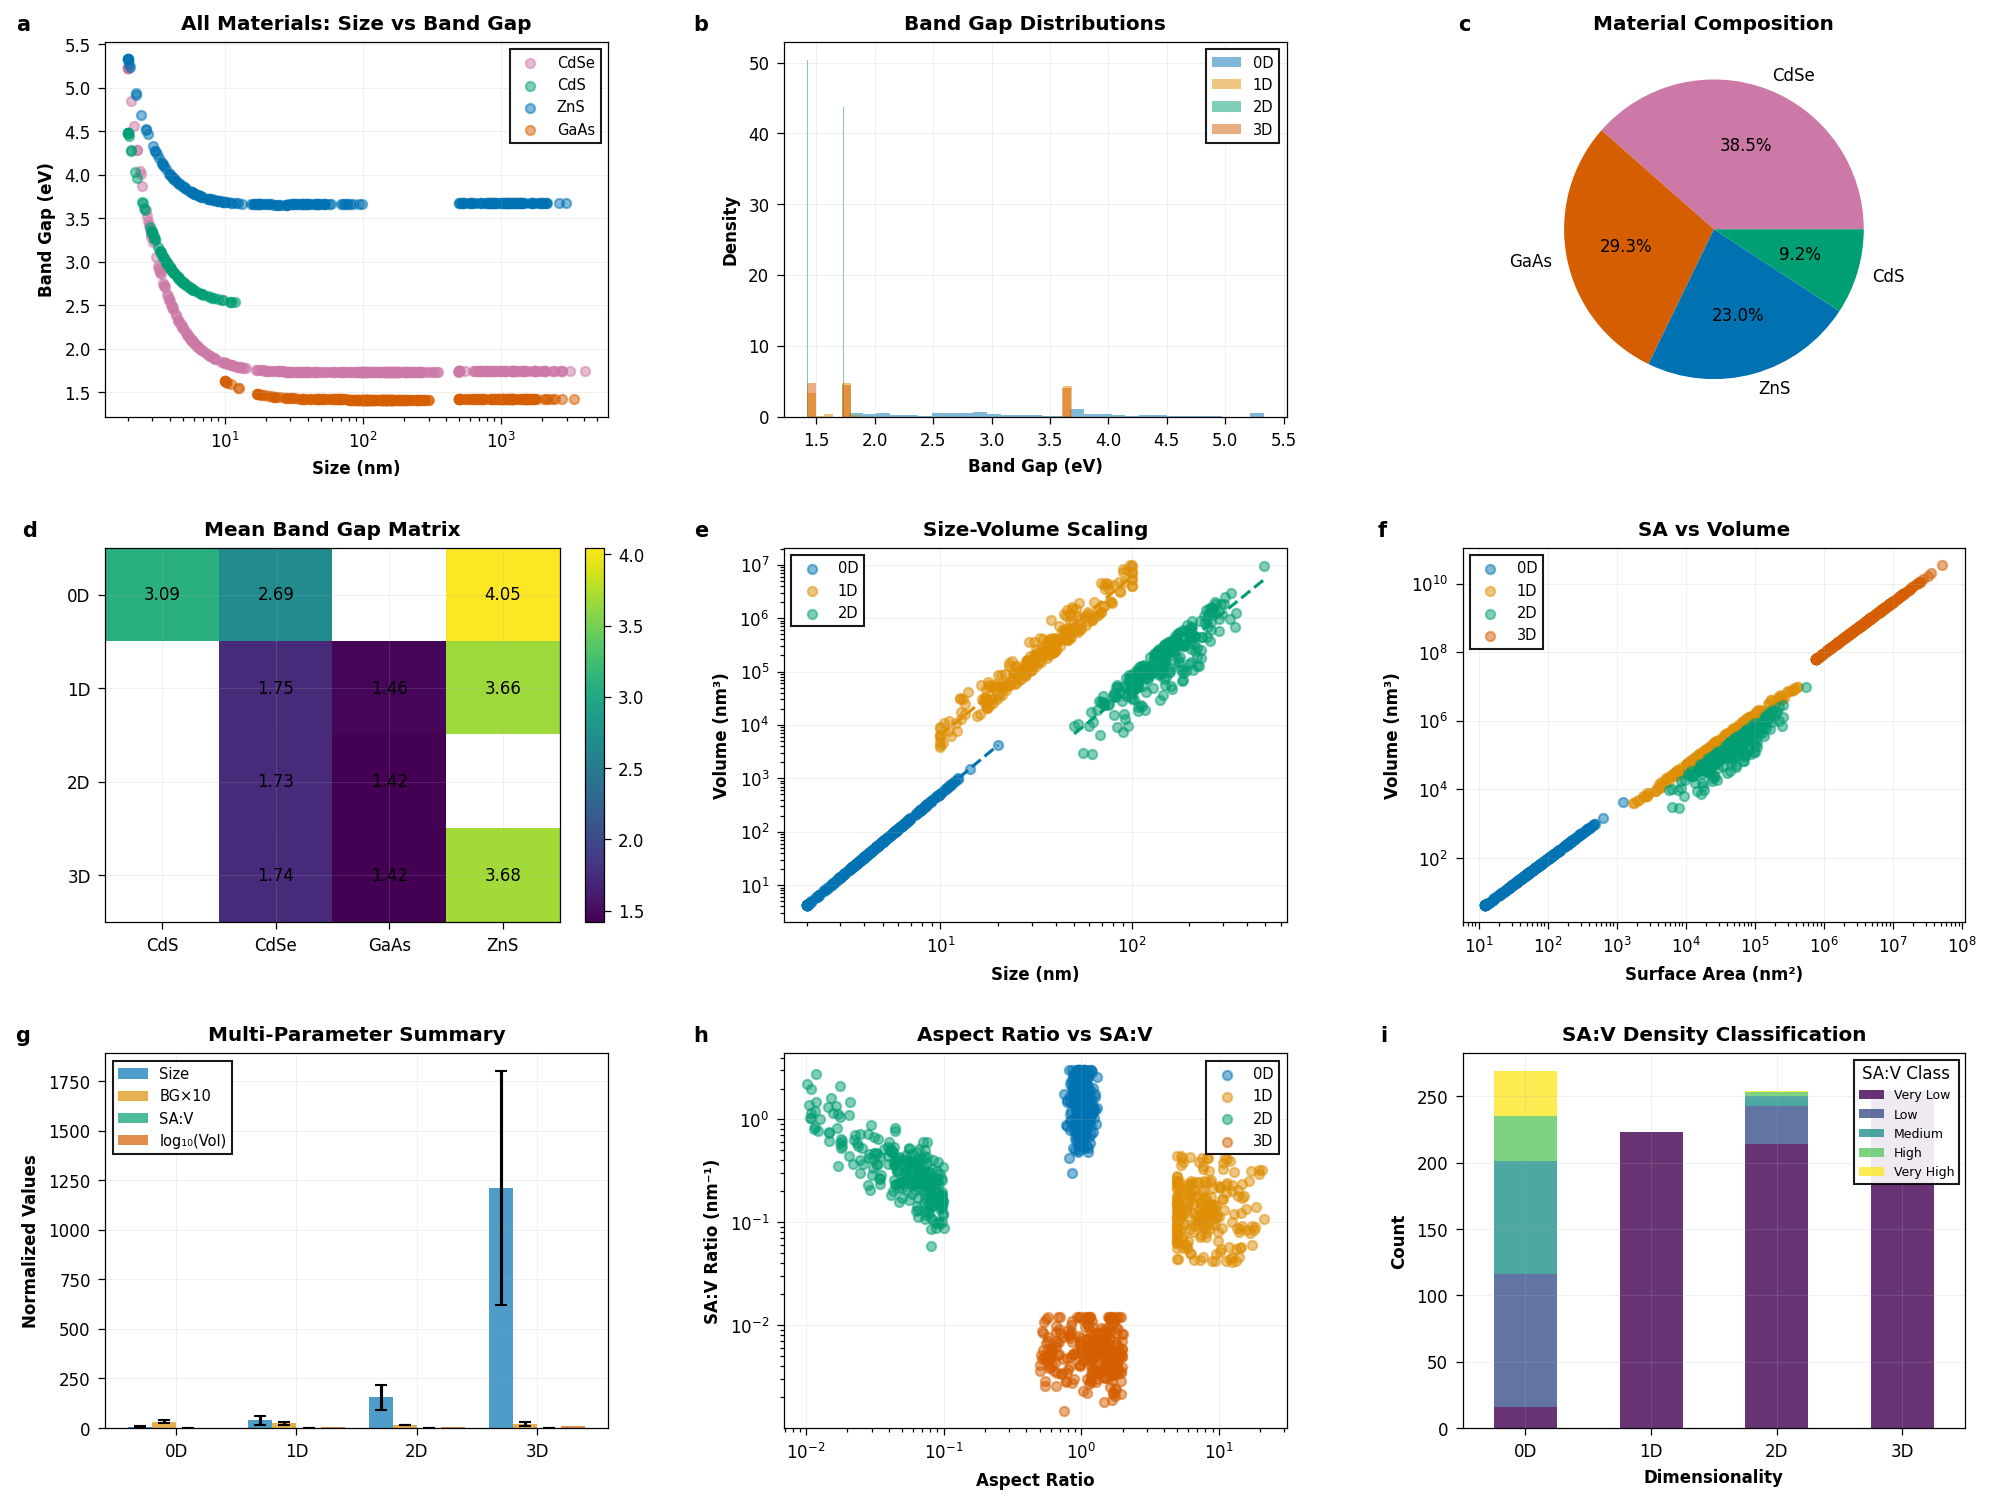


[PHASE 7] Statistical Analysis

COMPREHENSIVE STATISTICAL ANALYSIS

[1] DESCRIPTIVE STATISTICS BY DIMENSIONALITY
------------------------------------------------------------
    size_nm                                                              \
      count       mean       std    min       25%        50%        75%   
dim                                                                       
0D    269.0     5.1890    2.6552    2.0    3.3212     4.5983     6.3432   
1D    223.0    38.8310   23.0643   10.0   21.0489    33.6574    47.9897   
2D    254.0   154.3476   64.4871   50.0  107.2751   143.9815   185.0974   
3D    254.0  1210.7460  590.7345  500.0  777.0764  1107.0550  1497.0479   

                bg_ev          ...       vol_nm3                   ar          \
           max  count    mean  ...           75%           max  count    mean   
dim                            ...                                              
0D     20.0000  269.0  3.2223  ...  1.336350e+02  4.1887

In [32]:
def generate_full_report():
    print("="*80)
    print("NANOMATERIAL CLASSIFICATION RESEARCH FRAMEWORK v2.0")
    print("Publication-Ready Scientific Analysis")
    print("="*80)

    print("\n[PHASE 1] Data Generation")
    print("-" * 60)
    dataset = NanoDataset(n=1000, seed=42)
    df = dataset.generate()
    print(f"Generated {len(df)} synthetic nanomaterial samples")
    print(f"Features: {list(df.columns)}")

    print("\n[PHASE 2] Data Validation")
    print("-" * 60)
    print(f"Missing values: {df.isnull().sum().sum()}")
    print(f"Duplicate IDs: {df['id'].duplicated().sum()}")
    print("\nDimensionality distribution:")
    for dim, count in df['dim'].value_counts().sort_index().items():
        print(f"  {dim}: {count} ({count/len(df)*100:.1f}%)")

    print("\nMaterial distribution:")
    for mat, count in df['mat'].value_counts().items():
        print(f"  {mat}: {count} ({count/len(df)*100:.1f}%)")

    print("\n[PHASE 3] Generating Figure 1: Quantum Confinement Analysis")
    fig1 = QuantumAnalysis()
    fig1.plot(df)

    print("\n[PHASE 4] Generating Figure 2: Surface Area Analysis")
    fig2 = SurfaceAnalysis()
    fig2.plot(df)

    print("\n[PHASE 5] Generating Figure 3: Machine Learning Analysis")
    fig3 = MLAnalysis()
    fig3.plot(df)

    print("\n[PHASE 6] Generating Figure 4: Comprehensive Analysis")
    fig4 = ComprehensiveAnalysis()
    _, comp_results = fig4.plot(df)

    print("\n[PHASE 7] Statistical Analysis")
    stats_results = statistical_analysis(df)

    print("\n[PHASE 8] Key Findings Summary")
    print("=" * 80)
    print(f"1. Quantum Confinement: 0D materials show {comp_results['mean_band_gaps']['0D']:.2f} eV average band gap")
    print(f"   vs {comp_results['mean_band_gaps']['3D']:.2f} eV for bulk (3D)")
    print(f"2. Surface Area: 0D has {comp_results['mean_sav']['0D']:.2f} nm⁻¹ SA:V ratio")
    print(f"   vs {comp_results['mean_sav']['3D']:.4f} nm⁻¹ for bulk")
    print(f"3. ANOVA F-statistic: {stats_results['anova_f']:.2f} (p < 0.001)")
    print(f"4. Strongest correlation: Size vs SA:V (r = {stats_results['correlation_matrix'].loc['size_nm', 'sav_nm']:.3f})")

    print("\n[OUTPUT] Files generated:")
    print("  - figure1_quantum_analysis.pdf/png")
    print("  - figure2_surface_analysis.pdf/png")
    print("  - figure3_ml_analysis.pdf/png")
    print("  - figure4_comprehensive.pdf/png")

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)

    return df, stats_results, comp_results

df, stats, comp = generate_full_report()